In [21]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

from sv3.nn import FunctionalModelJac, MLP
from sv3.svd_sgd import SVDOptimizer

import sys
sys.path.append('..')
import copy

from experiments.experiment_code.experiment_utils import train_loop_standard, train_loop_svd, set_seed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using device: cpu


### load data

In [22]:
from experiments.datasets import MNISTDataset

mnist = MNISTDataset()
train_dataset = mnist.train_dataset
test_dataset = mnist.val_dataset

### Define model

In [23]:
def make_model():
    return MLP(input_dim=784,
               hidden_dims=[4,4],
               output_dim=10)

set_seed(437438)
mlp_base = make_model()
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base # free memory

### Hessian for CE loss

In [24]:
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from torch.func import functional_call, hessian

model_init = make_model()
model_init = model_init.to(device)
param_name_shape_sizes = []
for name, param in model_init.named_parameters():
    param_name_shape_sizes.append((name, param.shape, param.numel()))

params_init = parameters_to_vector(model_init.parameters())  # (D,)

def loss_for_hessian(params_flat, X, Y):
    p = {}
    i = 0
    for (name, shape, size) in param_name_shape_sizes:
        p[name] = params_flat[i:i+size].view(shape)
        i += size
    pred = functional_call(model_init, p, X)
    
    loss = nn.CrossEntropyLoss(reduction='mean')(pred,Y)
    return loss

x = mnist.train_dataset[:500][0]
y = mnist.train_dataset[:500][1]

H = hessian(loss_for_hessian)(params_init, x, y).detach()

In [25]:
eigvals, eigvecs = torch.linalg.eigh(H)

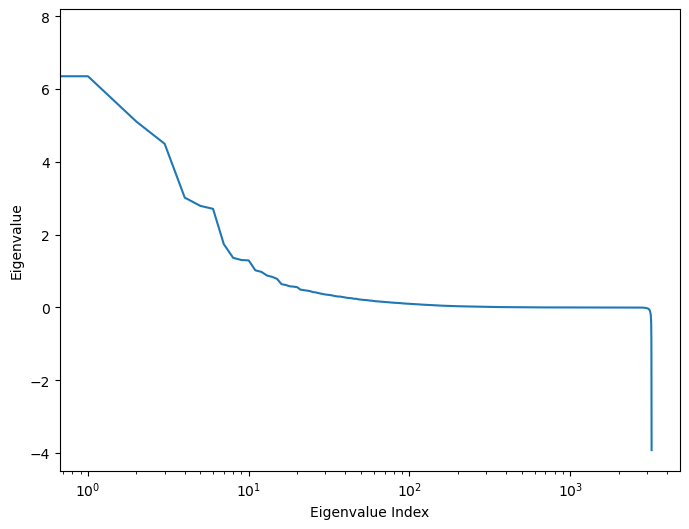

In [26]:
plt.figure(figsize=(8,6))
plt.plot(eigvals.numpy()[::-1])
plt.xlabel("Eigenvalue Index")
plt.ylabel("Eigenvalue")
plt.xscale('log')

### hessian for label regression loss

In [16]:
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from torch.func import functional_call, hessian

model_init = make_model()
model_init = model_init.to(device)
param_name_shape_sizes = []
for name, param in model_init.named_parameters():
    param_name_shape_sizes.append((name, param.shape, param.numel()))

params_init = parameters_to_vector(model_init.parameters())  # (D,)

def loss_for_hessian(params_flat, X, Y):
    p = {}
    i = 0
    for (name, shape, size) in param_name_shape_sizes:
        p[name] = params_flat[i:i+size].view(shape)
        i += size
    pred = functional_call(model_init, p, X)
    
    Y = F.one_hot(Y, num_classes=pred.shape[1]).to(pred)
    loss = (pred - Y).pow(2).sum(dim=1).mean()
    return loss

x = mnist.train_dataset[:500][0]
y = mnist.train_dataset[:500][1]

H = hessian(loss_for_hessian)(params_init, x, y).detach()

In [17]:
eigvals, eigvecs = torch.linalg.eigh(H)

Text(0, 0.5, 'Eigenvalue')

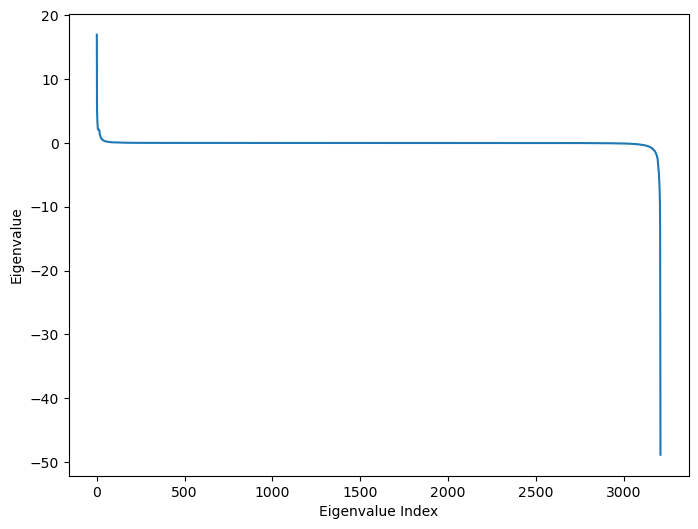

In [18]:
plt.figure(figsize=(8,6))
plt.plot(eigvals.numpy()[::-1])
plt.xlabel("Eigenvalue Index")
plt.ylabel("Eigenvalue")

Text(0, 0.5, 'Eigenvalue')

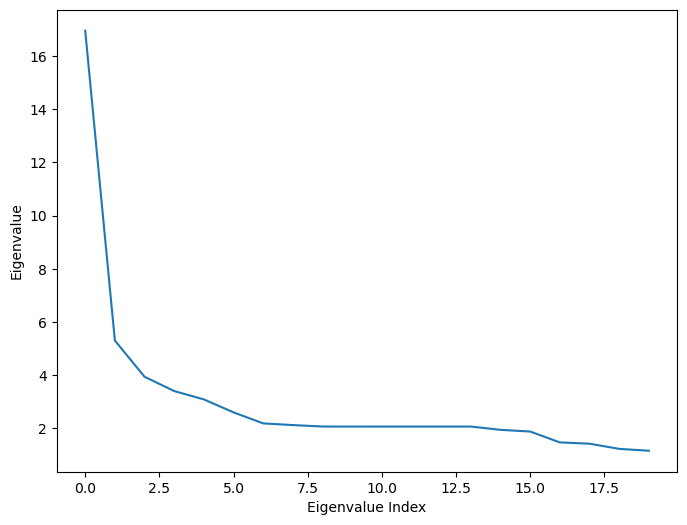

In [20]:
plt.figure(figsize=(8,6))
plt.plot(eigvals.numpy()[::-1][:20])

plt.xlabel("Eigenvalue Index")
plt.ylabel("Eigenvalue")